In [37]:
%load_ext autoreload
%autoreload 2

import platform
import pandas as pd
import os
import sys

system = platform.system()
if system == 'Linux':
    home = '/home/gerard/'
elif system == 'Darwin':
    home = '/Users/gerard/'
elif system == "Windows":
    home = 'C:/Users/cviko/'


try:
    sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
    from data_processing import *
    from utils import *
    from plotter import *
    from colocalization import *
except:
    path2add = home + 'analysis/confocal/src'
    sys.path.append(path2add)
    from data_processing import *
    from utils import *
    from plotter import *
    from colocalization import *

home = home + 'data/confocal/'



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
def df_separator(df):
    # 5x vs 1x
    keys = ['5x', '1x', '5x.alpha_', '5x.alphaprime_','5x.gamma_', '1x.alpha_', '1x.alphaprime_','1x.gamma_']
    dict_results = dict.fromkeys(keys) 
    for k in keys:
        ks = k.split('.')
        if len(ks) == 1:
            dict_results[k] = df[df['name'].str.contains(k, case=False, na=False)]
        else:
            dict_results[k] = df[
                            df['name'].str.contains(ks[0], case=False, na=False) &
                            df['name'].str.contains(ks[1], case=False, na=False)
                                                    ]
    return(dict_results)


In [39]:

user = 'Carmina'
dates = [
   # '2026_06_05',
    '2026_06_15', 
    '2026_06_25'
    ]
csv_files = [
    #'coloc_results', #coloc_results_2_raw',#'coloc_results_2', #'coloc_results
    'coloc_results',
    'coloc_results',

]

rows2drop = [
           # [],
            [
                'dec02_5x_brain3gamma_R8', 
                'dec02_5x_brain4alpha_L16' 
            ],
            []
                ]



df_list = [] 
for i, date in enumerate(dates):
    path_csv = home + date + '_' + user + f'/{csv_files[i]}.csv'
    df = pd.read_csv(path_csv)

    #TO EXCLUDE SOME ROWS:
    if rows2drop[i]:
        for name in rows2drop[i]:
   
            df = df.drop(df[df["name"] == name].index).reset_index(drop=True)
    ###########
    df_list.append(df)

pooled = (
    pd.concat(df_list, keys=dates, names=["date"])
    .reset_index(level="date")      # moves 'date' level out of the index into a column
    .reset_index(drop=True)         # replaces the remaining old-index level with plain 0..n
)
print(pooled.columns)
print(pooled['date'])
print(pooled['name'])






Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'density_HSP_syn', 'density_HSP_non_syn',
       'density_Mito_syn', 'density_Mito_non_syn',
       'MB_total_pearson_r HSP-Mito', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_pearson_r HSP-Mito',
       'MB_syn_fraction of HSP in Mito', 'MB_syn_fraction of Mito in HSP',
       'MB_syn_odds_ratio', 'MB_syn_enrichment',
       'MB_non_syn_pearson_r HSP-Mito', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'MB_syn_share of total HSP-Mito overlap',
       'MB_non_syn_share of total HSP-Mito overlap',
       'MB_syn_HSP-Mito colocalization density',
       'MB_non_syn_HSP-Mito colocalization density', 'snr_BRP', 'snr_HSP',
       'snr_Mito', '

In [6]:
#pooled[['name','MB_total_pearson_r HSP-Mito','MB_syn_pearson_r HSP-Mito','MB_non_syn_pearson_r HSP-Mito']]
#pooled[['name','MB_total_enrichment','MB_total_odds_ratio']]
#pooled[['date','name','snr_min_HSP_Mito','MB_total_enrichment','MB_total_odds_ratio']]


Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_fraction of HSP in Mito',
       'MB_syn_fraction of Mito in HSP', 'MB_syn_odds_ratio',
       'MB_syn_enrichment', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'snr_BRP', 'snr_HSP', 'snr_Mito',
       'snr_min_HSP_Mito']

Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_fraction of HSP in Mito',
       'MB_syn_fraction of Mito in HSP', 'MB_syn_odds_ratio',
       'MB_syn_enrichment', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 
       
       'MB_syn_share of total HSP-Mito overlap', <-----------
       'MB_non_syn_share of total HSP-Mito overlap',<-----------
       'MB_syn_HSP-Mito colocalization density',<-----------
       'MB_non_syn_HSP-Mito colocalization density',<-----------
       
       
        'snr_BRP', 'snr_HSP',
       'snr_Mito', 'snr_min_HSP_Mito'],


Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 
       
       'density_HSP_syn', <-----------
       'density_HSP_non_syn', <-----------
       'density_Mito_syn', <-----------
       'density_Mito_non_syn',<-----------
       
       
       'MB_total_fraction of HSP in Mito', 'MB_total_fraction of Mito in HSP',
       'MB_total_odds_ratio', 'MB_total_enrichment',
       'MB_syn_fraction of HSP in Mito', 'MB_syn_fraction of Mito in HSP',
       'MB_syn_odds_ratio', 'MB_syn_enrichment',
       'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'MB_syn_share of total HSP-Mito overlap',
       'MB_non_syn_share of total HSP-Mito overlap',
       'MB_syn_HSP-Mito colocalization density',
       'MB_non_syn_HSP-Mito colocalization density', 'snr_BRP', 'snr_HSP',
       'snr_Mito', 'snr_min_HSP_Mito'],
      dtype='str')

Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'density_HSP_syn', 'density_HSP_non_syn',
       'density_Mito_syn', 'density_Mito_non_syn',
       
       'MB_total_pearson_r HSP-Mito', <-----------
       
       'MB_total_fraction of HSP in Mito','MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 
       
       'MB_syn_pearson_r HSP-Mito', <-----------

       'MB_syn_fraction of HSP in Mito', 'MB_syn_fraction of Mito in HSP','MB_syn_odds_ratio','MB_syn_enrichment',
       
       'MB_non_syn_pearson_r HSP-Mito', <-----------
       
       'MB_non_syn_fraction of HSP in Mito','MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 
       
       'MB_syn_share of total HSP-Mito overlap',
       'MB_non_syn_share of total HSP-Mito overlap',
       'MB_syn_HSP-Mito colocalization density',
       'MB_non_syn_HSP-Mito colocalization density', 'snr_BRP', 'snr_HSP',
       'snr_Mito', 'snr_min_HSP_Mito'],
      dtype='str')

In [48]:
df_dict = df_separator(pooled)
print(df_dict.keys())
df_5x_1x = pd.concat([df_dict['5x'], df_dict['1x']], axis=1)
#df_5x_1x.head(10)
#fast_plotter(['prop_MB-HSP_in_syn'], df=df_5x_1x, ylabel='', title=title,
                        # bar_color=[['pink', 'hotpink']], quietStats=False, figsize=(6,6), legend=True)

dict_keys(['5x', '1x', '5x.alpha_', '5x.alphaprime_', '5x.gamma_', '1x.alpha_', '1x.alphaprime_', '1x.gamma_'])


,date,name,mask_HSP,mask_mito,mask_BRP,prop_MB_BRP,prop_MB_HSP,prop_MB_Mito,prop_MB-HSP_in_syn,prop_MB-Mito_in_syn,...,MB_non_syn_odds_ratio,MB_non_syn_enrichment,MB_syn_share of total HSP-Mito overlap,MB_non_syn_share of total HSP-Mito overlap,MB_syn_HSP-Mito colocalization density,MB_non_syn_HSP-Mito colocalization density,snr_BRP,snr_HSP,snr_Mito,snr_min_HSP_Mito
0,2026_06_15,dec02_5x_brain3gamma_R16,95.0,95.0,95.0,0.137,0.071,0.117,0.193,0.166,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026_06_15,dec02_5x_brain4alpha_L16new,95.0,95.0,95.0,0.083,0.082,0.142,0.120,0.122,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026_06_15,dec02_5x_brain4alphaprime_L16,95.0,95.0,95.0,0.032,0.100,0.154,0.056,0.057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026_06_15,dec02_5x_brain4gamma_L16,95.0,95.0,95.0,0.025,0.093,0.162,0.045,0.047,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026_06_15,dec02_5x_brain4alpha_R16,95.0,95.0,95.0,0.141,0.103,0.141,0.187,0.200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026_06_15,dec02_5x_brain4alphaprime_R16,95.0,95.0,95.0,0.112,0.122,0.158,0.166,0.173,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2026_06_15,dec02_5x_brain4gamma_R16,95.0,95.0,95.0,0.018,0.109,0.164,0.035,0.030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.746,1.483,0.352,0.648,0.0703,0.0257,36.411,35.808,61.275,35.808
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.888,1.566,0.334,0.666,0.0744,0.0259,4.551,11.389,51.884,11.389
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000,1.622,0.340,0.660,0.1256,0.0274,3.323,8.893,34.490,8.893


   density_HSP_syn_5x  density_HSP_non_syn_5x  density_HSP_syn_1x  \
0              0.0999                  0.0667              0.2109   
1              0.1178                  0.0782              0.2387   
2              0.1758                  0.0977              0.3457   
3              0.1675                  0.0913              0.1165   
4              0.1359                  0.0973              0.1167   
5              0.1806                  0.1144              0.0745   
6              0.2161                  0.1071              0.0862   
7                 NaN                     NaN              0.0846   
8                 NaN                     NaN              0.0888   
9                 NaN                     NaN              0.0842   

   density_HSP_non_syn_1x  
0                  0.1250  
1                  0.1248  
2                  0.1305  
3                  0.0982  
4                  0.0966  
5                  0.0843  
6                  0.0773  
7               

<string>:65: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


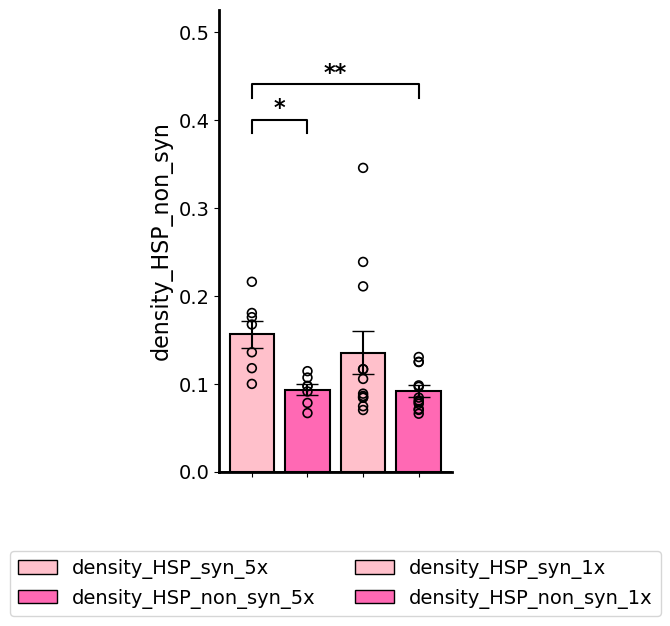

   density_HSP_syn_5x  density_HSP_non_syn_5x
0              0.0999                  0.0667
1              0.1178                  0.0782
2              0.1758                  0.0977
3              0.1675                  0.0913
4              0.1359                  0.0973
5              0.1806                  0.1144
6              0.2161                  0.1071
['density_HSP_syn_5x', 'density_HSP_non_syn_5x']

===== df_list[0] — 5x only (pooled, all regions combined) =====

---------- STATS ----------
density_HSP_syn_5x
  W statistic = 0.9662
  p-value     = 0.8696
  → Data look approximately normal

density_HSP_non_syn_5x
  W statistic = 0.9630
  p-value     = 0.8442
  → Data look approximately normal

Brown-Forsythe test
Statistic = 3.4890
p-value   = 0.0864
→ Variances are not significantly different

One-way ANOVA
F statistic = 14.6647
p-value     = 0.0024
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.5500
Effect size interpretation: large
  

<string>:65: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


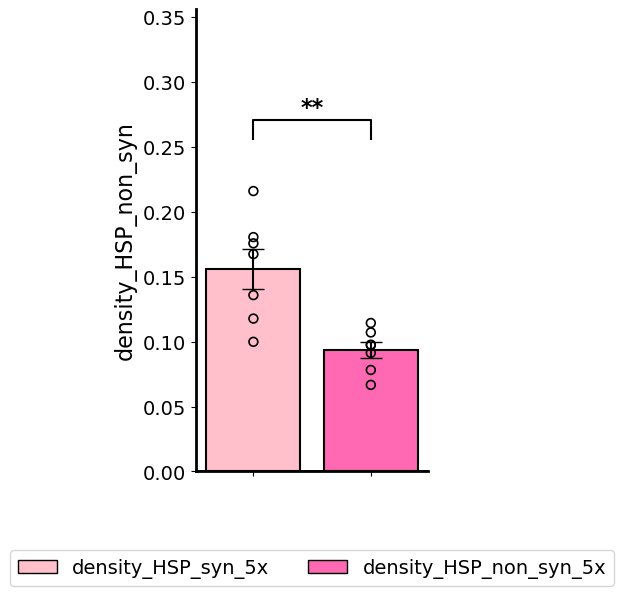

   density_HSP_syn_1x  density_HSP_non_syn_1x
0              0.2109                  0.1250
1              0.2387                  0.1248
2              0.3457                  0.1305
3              0.1165                  0.0982
4              0.1167                  0.0966
5              0.0745                  0.0843
6              0.0862                  0.0773
7              0.0846                  0.0713
8              0.0888                  0.0792
9              0.0842                  0.0703
['density_HSP_syn_1x', 'density_HSP_non_syn_1x']

===== df_list[0] — 1x only (pooled, all regions combined) =====

---------- STATS ----------
density_HSP_syn_1x
  W statistic = 0.7420
  p-value     = 0.0022
  → Significant deviation from normality

density_HSP_non_syn_1x
  W statistic = 0.8647
  p-value     = 0.0561
  → Data look approximately normal

Brown-Forsythe test
Statistic = 2.5982
p-value   = 0.1212
→ Variances are not significantly different

Mann-Whitney U test
U statistic = 94

<string>:65: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


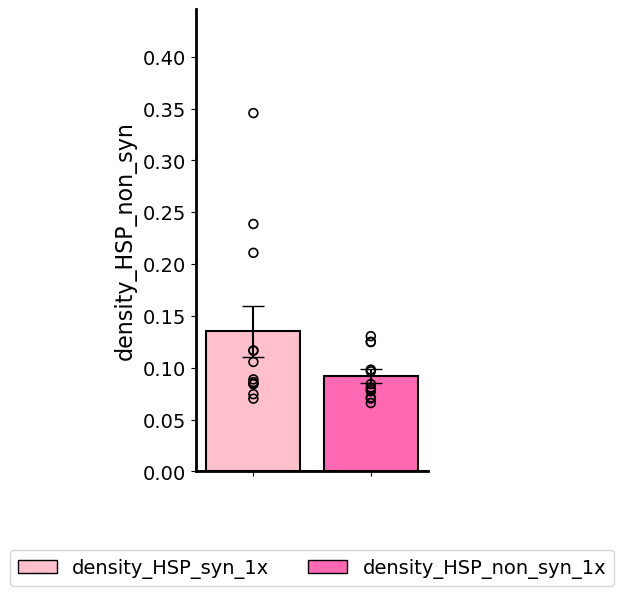

In [74]:

#colmns2plot = ['MB_syn_fraction of HSP in Mito', 'MB_non_syn_fraction of HSP in Mito']
#colmns2plot = ['MB_syn_fraction of Mito in HSP', 'MB_non_syn_fraction of Mito in HSP']

#colmns2plot = ['MB_syn_enrichment','MB_non_syn_enrichment']
#colmns2plot = ['MB_syn_odds_ratio', 'MB_non_syn_odds_ratio']
#colmns2plot = ['MB_syn_share of total HSP-Mito overlap', 'MB_non_syn_share of total HSP-Mito overlap',]
#colmns2plot = ['MB_syn_HSP-Mito colocalization density','MB_non_syn_HSP-Mito colocalization density']

#colmns2plot = ['prop_MB-HSP_in_syn', 'prop_MB-Mito_in_syn']
colmns2plot = ['density_HSP_syn','density_HSP_non_syn']
#colmns2plot = ['density_Mito_syn','density_Mito_non_syn']

#colmns2plot =['MB_syn_pearson_r HSP-Mito', 'MB_non_syn_pearson_r HSP-Mito']

#colmns2plot = ['prop_MB-Mito_in_syn']
df_list = [
        #df_raw,
        #df_deconv,
        # df_deconv_blind2, 
        # df_deconv_blind4,
        pooled, 
        # df_deconv_blind20,
                
         ]
colors = [["pink","hotpink"],["skyblue","royalblue"],["lightgreen","seagreen"],["gold","darkorange"]]


# '5x'/'1x' are pooled totals; the six '.'-keys are per-subregion breakdowns of the
# SAME rows (e.g. '5x.alpha_' rows are a subset of '5x' rows). Mixing pooled and
# subregion groups in one fast_plotter call would run ANOVA/Tukey on non-independent
# groups, so each combination below is plotted separately.
# Subregion (alpha/alphaprime/gamma) breakdown intentionally omitted here -- just
# the three pooled-all-regions comparisons below. Add a ("... by subregion", [...])
# entry back in if that breakdown is needed again later.
plot_configs = [
   ("5x vs 1x (pooled, all regions combined)", ['5x', '1x']),
    #("5x vs 1x by subregion", ['5x.alpha_', '5x.alphaprime_', '5x.gamma_',
    #                            '1x.alpha_', '1x.alphaprime_', '1x.gamma_']),
    ("5x only (pooled, all regions combined)", ['5x']),
   ("1x only (pooled, all regions combined)", ['1x']),
    #("1x only by subregion", ['1x.alpha_', '1x.alphaprime_', '1x.gamma_']),
]

for j,df in enumerate(df_list):
    df_dict = df_separator(df)

    for title, key_group in plot_configs:
        col_data = {}
        new_col_list = []
        for k in key_group:
            df_k = df_dict[k]
            for col in colmns2plot:
                new_col = f"{col}_{k}"
                new_col_list.append(new_col)
                # reset_index: each key's rows keep their original df index (disjoint
                # across keys), so assigning straight into a DataFrame would align on
                # that index and turn every group but the first into all-NaN columns.
                col_data[new_col] = df_k[col].reset_index(drop=True)
        all_df = pd.concat(col_data, axis=1)
        print(all_df.head(10))
        print(new_col_list)

        print(f"\n===== df_list[{j}] — {title} =====")

        # one color per column-type in colmns2plot, repeated once per key in key_group
        # (works for any combination of len(colmns2plot)/len(key_group), unlike a
        # fixed /2 divisor which breaks when colmns2plot has an odd length or 1 entry)
        bar_color = colors[j][:len(colmns2plot)] * len(key_group)
        
        
        fast_plotter(new_col_list, df= all_df, ylabel=col,  bar_color=bar_color,  quietStats=False, figsize=(3,6), legend=True)


   prop_MB-HSP_in_syn_5x  prop_MB-HSP_in_syn_1x
0                  0.193                  0.251
1                  0.120                  0.250
2                  0.056                  0.229
3                  0.045                  0.188
4                  0.187                  0.181
5                  0.166                  0.071
6                  0.035                  0.134
7                    NaN                  0.138
8                    NaN                  0.045
9                    NaN                  0.140
['prop_MB-HSP_in_syn_5x', 'prop_MB-HSP_in_syn_1x']

---------- STATS ----------
prop_MB-HSP_in_syn_5x
  W statistic = 0.8597
  p-value     = 0.1504
  → Data look approximately normal

prop_MB-HSP_in_syn_1x
  W statistic = 0.9349
  p-value     = 0.4353
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.0194
p-value   = 0.8908
→ Variances are not significantly different

One-way ANOVA
F statistic = 1.3696
p-value     = 0.2580
→ No significant differen

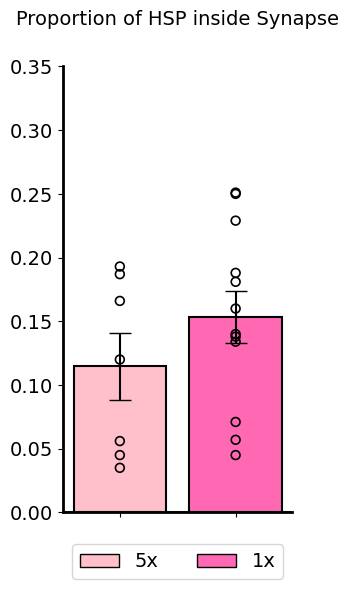

   prop_MB-Mito_in_syn_5x  prop_MB-Mito_in_syn_1x
0                   0.166                   0.261
1                   0.122                   0.236
2                   0.057                   0.204
3                   0.047                   0.203
4                   0.200                   0.186
5                   0.173                   0.027
6                   0.030                   0.125
7                     NaN                   0.128
8                     NaN                   0.036
9                     NaN                   0.132
['prop_MB-Mito_in_syn_5x', 'prop_MB-Mito_in_syn_1x']

---------- STATS ----------
prop_MB-Mito_in_syn_5x
  W statistic = 0.8945
  p-value     = 0.2990
  → Data look approximately normal

prop_MB-Mito_in_syn_1x
  W statistic = 0.9113
  p-value     = 0.2217
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.2821
p-value   = 0.6022
→ Variances are not significantly different

One-way ANOVA
F statistic = 0.7466
p-value     = 0.3996

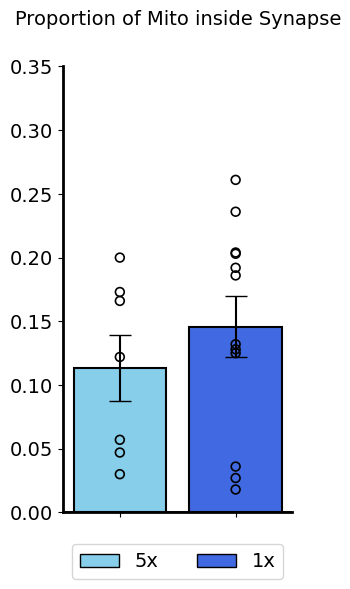

In [78]:

#colmns2plot = ['MB_syn_fraction of HSP in Mito', 'MB_non_syn_fraction of HSP in Mito']
#colmns2plot = ['MB_syn_fraction of Mito in HSP', 'MB_non_syn_fraction of Mito in HSP']

#colmns2plot = ['MB_syn_enrichment','MB_non_syn_enrichment']
#colmns2plot = ['MB_syn_odds_ratio', 'MB_non_syn_odds_ratio']
#colmns2plot = ['MB_syn_share of total HSP-Mito overlap', 'MB_non_syn_share of total HSP-Mito overlap',]
#colmns2plot = ['MB_syn_HSP-Mito colocalization density','MB_non_syn_HSP-Mito colocalization density']

colmns2plot = ['prop_MB-HSP_in_syn', 
               'prop_MB-Mito_in_syn'
               ]


titles= ['Proportion of HSP inside Synapse', 
         'Proportion of Mito inside Synapse',
         ]


colors = [["pink","hotpink"],["skyblue","royalblue"],["lightgreen","seagreen"],["gold","darkorange"]]



        
        
ks = ['5x', '1x']     
for jj, col in enumerate(colmns2plot):
    all_df = pd.DataFrame()
    col_data = {}
    new_col_list = []
    for k in ks:
        df_k = df_dict[k]
        new_col = f"{col}_{k}"
        new_col_list.append(new_col)
   
        col_data[new_col] = df_k[col].reset_index(drop=True)
        
    all_df = pd.concat(col_data, axis=1)
    print(all_df.head(10))
    print(new_col_list)

    bar_color = colors[jj]#colors[j][:len(colmns2plot)] * len(key_group)
    title = titles[jj]

    fast_plotter(new_col_list, df= all_df, ylabel='',  labels=ks, bar_color=bar_color, title=title, quietStats=False, figsize=(3,6), legend=True)


***GENERAL DESCRIPTION OF THE DISTRIBUTIONS:

In [29]:
def plot_metric_group(colmns2plot, df_list, colors, plot_configs, ylabel='', title=''):
    """Reusable version of the plotting loop above: builds one `{col}_{key}` column
    per (column, group-key) pair and bar-plots them together with fast_plotter's
    stats. `title`, if given, is passed through to every fast_plotter call as-is
    (on top of the per-plot_config `cfg_title` printed above each block) -- note
    the loop variable below is named `cfg_title`, not `title`, precisely so it
    doesn't shadow this parameter.
    """
    for j, df in enumerate(df_list):
        df_dict = df_separator(df)

        for cfg_title, key_group in plot_configs:
            col_data = {}
            new_col_list = []
            for k in key_group:
                df_k = df_dict[k]
                for col in colmns2plot:
                    new_col = f"{col}_{k}"
                    new_col_list.append(new_col)
                    # reset_index: each key's rows keep their original df index (disjoint
                    # across keys), so assigning straight into a DataFrame would align on
                    # that index and turn every group but the first into all-NaN columns.
                    col_data[new_col] = df_k[col].reset_index(drop=True)
            all_df = pd.concat(col_data, axis=1)

            print(f"\n===== df_list[{j}] — {cfg_title} =====")

            # one color per column-type in colmns2plot, repeated once per key in key_group
            # (works for any combination of len(colmns2plot)/len(key_group), unlike a
            # fixed /2 divisor which breaks when colmns2plot has an odd length or 1 entry)
            bar_color = colors[j][:len(colmns2plot)] * len(key_group)
            fast_plotter(new_col_list, df=all_df, ylabel=ylabel, title=title,
                         bar_color=bar_color, quietStats=False, figsize=(6,6), legend=True)



===== df_list[0] — 5x vs 1x (pooled, all regions combined) =====

---------- STATS ----------
prop_MB-HSP_in_syn_5x
  W statistic = 0.8597
  p-value     = 0.1504
  → Data look approximately normal

prop_MB-HSP_in_syn_1x
  W statistic = 0.9349
  p-value     = 0.4353
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.0194
p-value   = 0.8908
→ Variances are not significantly different

One-way ANOVA
F statistic = 1.3696
p-value     = 0.2580
→ No significant differences detected


Effect size
Eta squared (η²) = 0.0746
Effect size interpretation: medium
              Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj  lower  upper  reject
--------------------------------------------------------------------------------
prop_MB-HSP_in_syn_1x prop_MB-HSP_in_syn_5x  -0.0391 0.258 -0.1096 0.0314  False
--------------------------------------------------------------------------------
prop_MB-HSP_in_syn_5

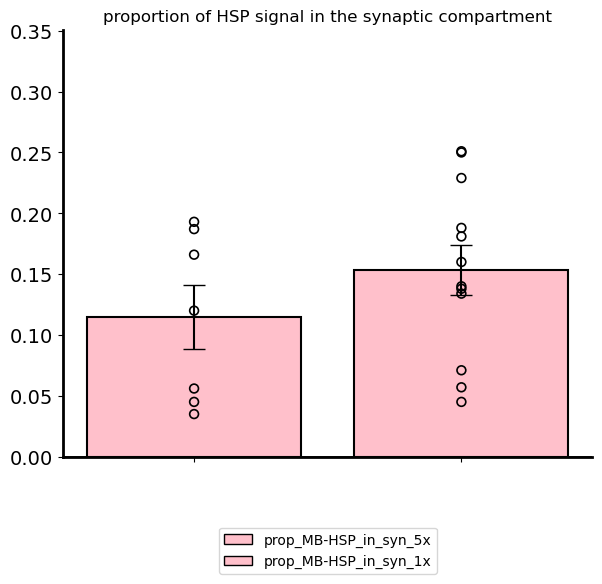

In [35]:
# What fraction of each channel's total MB signal sits in the synaptic (BRP+)
# compartment? prop_MB-*_in_syn is a single value per channel per brain (not a
# syn/non_syn pair -- the non-synaptic share is just 1 minus this), so this
# compares HSP's vs Mito's confinement to synapses, not two ends of one channel.
plot_metric_group(
    [
        'prop_MB-HSP_in_syn'
     ,# 'prop_MB-Mito_in_syn'
     ],
    df_list, [['pink'], ['hotpink']], plot_configs,
    title='proportion of HSP signal in the synaptic compartment',
)


[          date                           name  mask_HSP  mask_mito  mask_BRP  \
 0   2026_06_15       dec02_5x_brain3gamma_R16        95         95        95   
 1   2026_06_15    dec02_5x_brain4alpha_L16new        95         95        95   
 2   2026_06_15  dec02_5x_brain4alphaprime_L16        95         95        95   
 3   2026_06_15       dec02_5x_brain4gamma_L16        95         95        95   
 4   2026_06_15       dec02_5x_brain4alpha_R16        95         95        95   
 5   2026_06_15  dec02_5x_brain4alphaprime_R16        95         95        95   
 6   2026_06_15       dec02_5x_brain4gamma_R16        95         95        95   
 7   2026_06_15       dec02_1x_brain1alpha_L16        95         95        95   
 8   2026_06_15  dec02_1x_brain1alphaprime_L16        95         95        95   
 9   2026_06_15       dec02_1x_brain1gamma_L16        95         95        95   
 10  2026_06_25       dec02_1x_brain1alpha_R16        95         95        95   
 11  2026_06_25  dec02_1x_br


===== df_list[0] — 5x vs 1x (pooled, all regions combined) =====

---------- STATS ----------
density_Mito_syn_5x
  W statistic = 0.9526
  p-value     = 0.7529
  → Data look approximately normal

density_Mito_non_syn_5x
  W statistic = 0.9467
  p-value     = 0.6994
  → Data look approximately normal

density_Mito_syn_1x
  W statistic = 0.9397
  p-value     = 0.4947
  → Data look approximately normal

density_Mito_non_syn_1x
  W statistic = 0.9749
  p-value     = 0.9546
  → Data look approximately normal

Brown-Forsythe test
Statistic = 6.3379
p-value   = 0.0016
→ Variances differ significantly

Kruskal-Wallis test
H statistic = 12.1397
p-value     = 0.0069
→ Significant differences exist between groups

density_Mito_syn_5x vs density_Mito_non_syn_5x: p_adj = 0.0350 *
density_Mito_syn_5x vs density_Mito_syn_1x: p_adj = 0.3130 ns
density_Mito_syn_5x vs density_Mito_non_syn_1x: p_adj = 0.0157 *
density_Mito_non_syn_5x vs density_Mito_syn_1x: p_adj = 0.3130 ns
density_Mito_non_syn_5x vs d

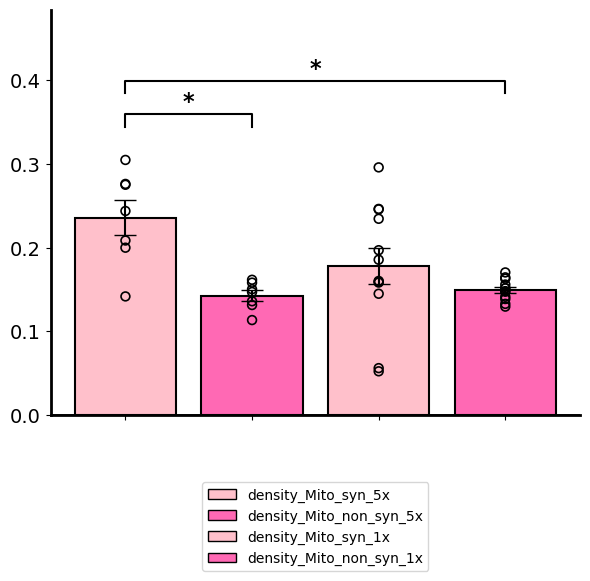

In [33]:
# Mito signal concentration (per unit volume) in the synaptic vs non-synaptic
# compartment -- is mitochondrial density itself higher near synapses?
plot_metric_group(
    ['density_Mito_syn', 'density_Mito_non_syn'],
    df_list, [['pink', 'hotpink']], plot_configs,
)

